
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DeepRLCourse/Homework-2-Questions/blob/main/HW2_P2_DQN_vs_DDQN.ipynb) [![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/DeepRLCourse/Homework-2-Questions/blob/main/HW2_P2_DQN_vs_DDQN.ipynb)

# **HW: DQN vs DDQN**
---


> - Full Name: **َFatima Timarchi**
> - Student ID: **402105802**

> - توضیح در مورد کد ها :
<div style="direction: rtl; text-align: right; font-family: Vazir;">
به علت استیبل نبودن اینترنت برخی یادگیری تسک ها زمان زیادی میبردند و مطابق پیام فرستاده شده در تلگرام من برای این تسک ها مقدار اپیزود هارو کمتر دادم تا کدم کامل اجرا بشه و خروجی بده.
</div>

## **Overview**

DQN, introduced in 2013, revolutionized deep reinforcement learning.  
In this notebook, you'll use PyTorch to train a Deep Q-Learning (DQN) agent on the [Cart-Pole](https://gymnasium.farama.org/environments/classic_control/cart_pole/) task from [Gymnasium](https://gymnasium.farama.org/). You'll also implement Double DQN (DDQN), an improved version with better stability, convergence, and test performance.

### In this notebook:
- Explore the Cart-Pole environment and observe an untrained agent.
- Set up a Gymnasium environment.
- Implement and train DQN and DDQN from scratch.
- Compare their performance to understand strengths and weaknesses.
- Render the trained agent’s behavior.

Before starting, import the necessary packages. Helper functions are provided for visualization and rendering.


## **Setup**  

First, install the required packages. If you're using Colab, everything should work smoothly. However, on a local system, you may encounter some dependency installation challenges.  


In [1]:
!sudo apt-get update --quiet
!pip install imageio --quiet
!sudo apt-get install -y xvfb ffmpeg --quiet
!pip install swig --quiet
!pip install gymnasium[box2d]

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.0 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,361 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,904 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-up

In [2]:
import gymnasium as gym
import random
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
from collections import namedtuple, deque

import base64
import json
import imageio
import IPython

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F


# if GPU is to be used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## **Helper Functions**  
This section contains functions for visualizing your results.  


In [3]:
# @title helper functions

# disable warnings
import logging
logging.getLogger().setLevel(logging.ERROR)

# set up matplotlib
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display
plt.ion()
plt.xkcd(scale=1, length=100, randomness=2)
matplotlib.rcParams['figure.figsize'] = (12, 6)


def plot_rewards(sum_of_rewards,i,show_result=False):
    plt.figure(1)
    rewards = torch.tensor(sum_of_rewards, dtype=torch.float)
    if show_result:
        plt.title('Result')
    else:
        plt.clf()
        plt.title(f'Training the Agent number {i}')
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    plt.plot(rewards.numpy())
    # Take 50 episode averages and plot them too
    length = len(rewards)
    init_len = min(49, length)
    init_means = np.cumsum(rewards[:init_len]) / (1 + np.arange(init_len))
    if length > 50:
        means = rewards.unfold(0, 50, 1).mean(1).view(-1)
        means = torch.cat((init_means, means))
    else:
        means = init_means
    plt.plot(means.numpy())

    plt.pause(0.001)
    if is_ipython:
        if not show_result:
            display.display(plt.gcf())
            display.clear_output(wait=True)
        else:
            display.display(plt.gcf())

def plot_smooth(DDQN_mean_rewards,DDQN_min_rewards,DDQN_max_rewards,DQN_mean_rewards,DQN_min_rewards,DQN_max_rewards):
      plt.figure(figsize=(12,7))

      # Plot DDQN
      DDQN, = plt.plot(range(len(DDQN_mean_rewards)), DDQN_mean_rewards, color='blue', label='DDQN')
      plt.fill_between(range(len(DDQN_min_rewards)), DDQN_min_rewards, DDQN_max_rewards, color='blue', alpha=0.2)

      # Plot DQN
      DQN, = plt.plot(range(len(DQN_mean_rewards)), DQN_mean_rewards, color='red', label='DQN')
      plt.fill_between(range(len(DQN_min_rewards)), DQN_min_rewards, DQN_max_rewards, color='red', alpha=0.2)

      # Fix legend
      plt.legend(handles=[DDQN, DQN])
      plt.show()



def plot_values(values):
    plt.figure(figsize=(15, 9))

    # Iterate over each value set
    for i, value in enumerate(values):
        for n, Data in enumerate(value):
            plt.plot(range(len(Data)), Data, label=f"Values of selected trained Agent Number {i+1}, Evaluation {n+1}")

    plt.title('Test Episode Mean Q values')
    plt.xlabel("Episodes")
    plt.ylabel("Value")
    plt.grid(True)
    plt.legend()
    plt.show()



def embed_mp4(filename):
    video = open(filename,'rb').read()
    b64 = base64.b64encode(video)
    tag = '''
    <video width="640" height="480" controls>
    <source src="data:video/mp4;base64,{0}" type="video/mp4">
    Your browser does not support the video tag.
    </video>'''.format(b64.decode())
    return IPython.display.HTML(tag)


def create_policy_eval_video(env, agent, filename, num_episodes=1, fps=30):
    filename = filename + ".mp4"
    with imageio.get_writer(filename, fps=fps) as video:
        for _ in range(num_episodes):
            state, info = env.reset()
            video.append_data(env.render())
            while True:
                state = torch.from_numpy(state).unsqueeze(0).to(device)
                action,_ = agent.act(state, greedy=True)
                state, reward, terminated, truncated, info = env.step(action)
                video.append_data(env.render())
                if terminated or truncated:
                    break
    return embed_mp4(filename)


def save_progress(sum_of_rewards, PATH):
    # Convert the list to a JSON string
    json_data = json.dumps(sum_of_rewards)
    # Write the JSON data to a file
    with open(PATH + str('.json'), "w") as file:
        file.write(json_data)


def load_progress(PATH):
    with open(PATH + str('.json'), "r") as file:
        json_data = file.read()
    # Load the JSON data back into a Python list
    return json.loads(json_data)

# **Explore the Environment (5 points)**

Let's explore the Gym Cart-Pole environment.  
First, we need to create the environment and set `rgb_array` as the render mode for visualization.  


In [4]:
env = gym.make("CartPole-v1", render_mode="rgb_array")
print('Observations:', env.observation_space.shape[0])
print('Actions:', env.action_space.n)


Observations: 4
Actions: 2


Complete the following class to create an agent that selects actions randomly from the action space.  


In [5]:
class RandomAgent():

    def __init__(self, env_name, mode='rgb_array'):
        self.env = gym.make(env_name, render_mode='rgb_array')

    def act(self, state=None, greedy=None):
        action = self.env.action_space.sample()
        return action, 0

**Monitor the random Agent perfomance**

In [6]:
random_agent = RandomAgent("CartPole-v1")
create_policy_eval_video(random_agent.env, random_agent, 'random_policy', num_episodes=5)

## **Main Components of DDQN and Its Variants**  

### **Deep Q Network (DQN)**  

DQN uses a neural network to estimate $Q(s,a)$ values. In theory, the network takes both state and action as input and outputs a single $Q(s,a)$ value. However, in practice, it takes only the state as input and outputs a vector of Q-values, where each value corresponds to an action in the action space.  

<img src="figs/network.jpg" style="margin-left: 300px;">  

Now, let's define the Deep Q Network.  


In [7]:

class QNetwork(nn.Module):

  def __init__(self, state_size, action_size):

      super(QNetwork, self).__init__()

      self.relu = nn.ReLU()
      self.fc1 = nn.Linear(state_size, 512)
      self.fc2 = nn.Linear(512,125)
      self.fc3 = nn.Linear(125,action_size)


  def forward(self, state):

    x = self.relu(self.fc1(state))
    x = self.relu(self.fc2(x))
    x = self.relu(self.fc3(x))

    return x



## **Experience Replay Buffer**  

To train the network, we need data. We store **transitions**—tuples of (state, action, reward, next state, termination)—in a replay buffer for later sampling.  

- **state (s):** The current situation the agent is experiencing.  
- **action (a):** The action taken by the agent.  
- **next state (s'):** The new state after taking the action.  
- **reward (r):** The feedback received for the action.  
- **termination (done):** A boolean indicating if the episode has ended.  

These transitions are stored in the **Experience Replay Buffer**, allowing us to sample and train the Q-network efficiently.  not using replay buffer would make the learing highly unstable and inefficient.

A stack of transitions $(s, a, s', r, done)$ looks like this:  

<img src="figs/buffer.png" style="margin-left: 300px;">  

**We shuffle the sampled data to break temporal correlations before training.**  

Now, let's define the Experience Replay Buffer class.  


## **Experience Replay Buffer**  

- `push`: Stores transitions from the environment.  
- `sample`: Shuffles and samples transitions.  
- `__len__` Returns the number of stored transitions.  
- `get_size`: Returns the buffer size  `__len__` as an output.  


In [8]:
class ReplayMemory(object):

    def __init__(self, capacity, batch_size):
        self.memory = deque([],maxlen = capacity)
        self.batch_size = batch_size
        self.experience = namedtuple("Experience", field_names = ("state", "action", "reward", "next_state", "done"))

    def push(self, state, action, reward, next_state, done):
            e = self.experience(state, action, reward, next_state, done)
            self.memory.append(e)

    def sample(self, batch_size = None):

            if batch_size is None:
                   batch_size = self.batch_size
            experiences = random.sample(self.memory, k = batch_size)
            states = np.vstack([e.state.detach().cpu() for e in experiences if e is not None])
            actions = np.vstack([e.action for e in experiences if e is not None])
            rewards = np.vstack([e.reward for e in experiences if e is not None])
            next_states = np.vstack([e.next_state.detach().cpu() for e in experiences if e is not None])
            dones = np.vstack([e.done for e in experiences if e is not None]).astype(np.uint8)
            return states, actions, rewards, next_states, dones

    def __len__(self):
              return len(self.memory)

    def get_size(self):
        return self.__len__()

## **DQN Agent**  

DQN, the first Deep RL algorithm, uses TD learning similar to Q-learning, aiming to minimize the distance:  

$r_i + \gamma \cdot max_{a'} Q_\theta'(s_i',a_i') - Q_\theta(s_i,a_i)$  

The more appropriate cost function is:  

$[r_i + \gamma \cdot max_{a'} Q_\theta(s_i',a_i') - Q_\theta(s_i,a_i)]^2$  $(1)$  

Instead of a tabular method, DQNs use deep networks to estimate Q-values.  

In this class, we implement the original DQN with an experience replay buffer. The training process is as follows:  

**Network Updating**  

1. Gather data. Once the buffer reaches a certain size, start training the Q-networks.  
2. Sample transitions and feed the States (instead of State-action pairs) to the Q-network to estimate $Q_\theta(s_i,a_i)$.  
3. Feed Next_States to the Q-network to estimate $Q_\theta(s_i',a_i')$.  
4. Use the average of equation $(1)$ to update the network via backpropagation.  


## **$\epsilon-\text{greedy policy}$**  

Exploration is crucial in RL algorithms. In DQN, exploration is achieved using the $\epsilon-\text{greedy policy}$.

$$
\pi(a \mid s) =
\begin{cases}
\arg\max\limits_{a} Q(s, a), & \text{with probability } 1 - \epsilon, \\
\text{random action}, & \text{with probability } \epsilon.
\end{cases}
$$


With probability $\epsilon$, a random action is chosen for exploration, and with probability $1 - \epsilon$, the best action is selected for exploitation.  

$\epsilon$ starts high and gradually decreases over time. The decay follows this formula:

$$\varepsilon = \varepsilon_{end} + \left(\varepsilon_{start} - \varepsilon_{end}\right)\exp\left(-\frac{\text{steps done}}{\text{decay rate}}\right)$$  

**The $\epsilon-\text{greedy policy}$ is used in both DQN and DDQN.**  

## **Original DQN Pseudocode**  

<img src="figs/DQN.png" style="margin-left: 300px;">  

### Properties of the Algorithm:

- Uses a single network to estimate both $Q(s,a)$ and $Q(s',a')$, which can lead to instability—this is the problem DDQN aims to solve. **It's up to you to figure out why this is a problem.**  
- Utilizes the $\epsilon-\text{greedy}$ policy for exploration.

**Hint:**  
- A single network leads to unstable learning, hence the introduction of a target network in modified versions.  
- The $\epsilon-\text{greedy}$ policy can sometimes hinder the learning process, despite addressing the exploration problem.  

## **Implementing DQN class (20 points)**


In [9]:
import copy
class DQNAgent(object):

    def __init__(self, q_network, memory, optimizer, criterion, params):
        self.policy_net = q_network
        self.target_net = copy.deepcopy(self.policy_net)
        self.target_net.eval()

        self.reply_buffer = memory

        self.criterion = criterion()
        self.optimizer = optimizer(self.policy_net.parameters(), lr=params['LR'], amsgrad=True)

        self.gamma = params['GAMMA']
        self.eps = {'START': params['EPS_START'], 'END': params['EPS_END'], 'DECAY': params['EPS_DECAY']}
        self.steps_done = 0
        self.Loss = []

        with torch.no_grad():
            try:
                self.action_size = self.policy_net.fc3.out_features
            except Exception:
                self.action_size = None

    def step(self, state, action, reward, next_state, done):
        self.steps_done = self.steps_done + 1
        self.reply_buffer.push(state, action, reward, next_state, done)

        if self.reply_buffer.get_size() > self.reply_buffer.batch_size:
            states, actions, rewards, next_states, dones = self.reply_buffer.sample()
            loss = self.learn(states, actions, rewards, next_states, dones)
            self.Loss.append(loss)

    def act(self, state, greedy=False):
        self.eps_threshold = self.eps['END'] + (self.eps['START'] - self.eps['END']) * np.exp(- self.steps_done / self.eps['DECAY'])

        if greedy or random.random() > self.eps_threshold:
            with torch.no_grad():
                Q_values = self.policy_net(state)
                action = torch.argmax(Q_values, dim=1).item()
                max_Q = torch.max(Q_values).item()
        else:
            if self.action_size is None:
                with torch.no_grad():
                    Q_values = self.policy_net(state)
                self.action_size = Q_values.shape[1]
            action = random.randrange(self.action_size)
            max_Q = 0

        return action, max_Q

    def learn(self, states, actions, rewards, next_states, dones):
        states = torch.from_numpy(states).float().to(device)
        actions = torch.from_numpy(actions).long().to(device)
        rewards = torch.from_numpy(rewards).float().to(device)
        next_states = torch.from_numpy(next_states).float().to(device)
        dones = torch.from_numpy(dones).float().to(device)

        state_Q = self.policy_net(states).gather(1, actions)

        with torch.no_grad():
            next_state_Q = self.policy_net(next_states).max(1)[0].unsqueeze(1)
            target_Q = rewards + (self.gamma * next_state_Q * (1 - dones))

        loss = self.criterion(state_Q, target_Q)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def save(self, PATH):
        torch.save(self.policy_net, PATH + '_policy.pt')
        torch.save(self.target_net, PATH + '_target.pt')

    def load(self, PATH):
        self.policy_net = torch.load(PATH + '_policy.pt')
        self.target_net = torch.load(PATH + '_target.pt')

# **Training the DQN Agents**

Now that you've implemented DQN and explored the Gym CartPole environment, it's time to train an actual agent.  

**First, we train the DQN agent.**  


## **Setting Up Essentials for DQN (5 points)**  

- **CartPole Environment Setup**  
- **Hyperparameter Initialization**  
- **Creating DQN Agents with Different Random Seeds**  
  - Why? Training multiple agents with different seeds helps assess DQN's consistency and robustness.  
  - We use **5 random seeds** for better evaluation.  
- **Defining Optimizer and Loss Function**  


In [10]:
def create_dqn_agent(seed, QNetwork, ReplayMemory, optimizer, criterion, params):
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

    q_net = QNetwork(params['N_OBS'], params['N_ACT']).to(device)
    memory = ReplayMemory(params['BUFFER_SIZE'], params['BATCH_SIZE'])
    return DQNAgent(q_net, memory, optimizer, criterion, params)


params = {
    'BUFFER_SIZE': 10000,
    'BATCH_SIZE': 64,
    'GAMMA': 0.99,
    'EPS_START': 1.0,
    'EPS_END': 0.05,
    'EPS_DECAY': 2000,
    'LR': 1e-3
}

seeds = [1, 10, 15, 43, 63]

env = gym.make("CartPole-v1")
env.reset()

n_actions = env.action_space.n
n_observations = env.observation_space.shape[0]

params['N_ACT'] = n_actions
params['N_OBS'] = n_observations

optimizer = torch.optim.AdamW
criterion = torch.nn.MSELoss

DQN_agents = []
dqn_sum_of_rewards = []

for seed in seeds:
    dqn_Agent = create_dqn_agent(seed, QNetwork, ReplayMemory, optimizer, criterion, params)
    DQN_agents.append(dqn_Agent)
    dqn_sum_of_rewards.append([])

## **Training Loop for the DQN Agent (10 points)**  

With the hyperparameters set, we can now train the agent.  

The code is designed for convenient retraining. simply re-run the segment to continue training if the agent hasn’t achieved satisfactory results.  


/tmp/ipython-input-2925360218.py:30: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  init_means = np.cumsum(rewards[:init_len]) / (1 + np.arange(init_len))


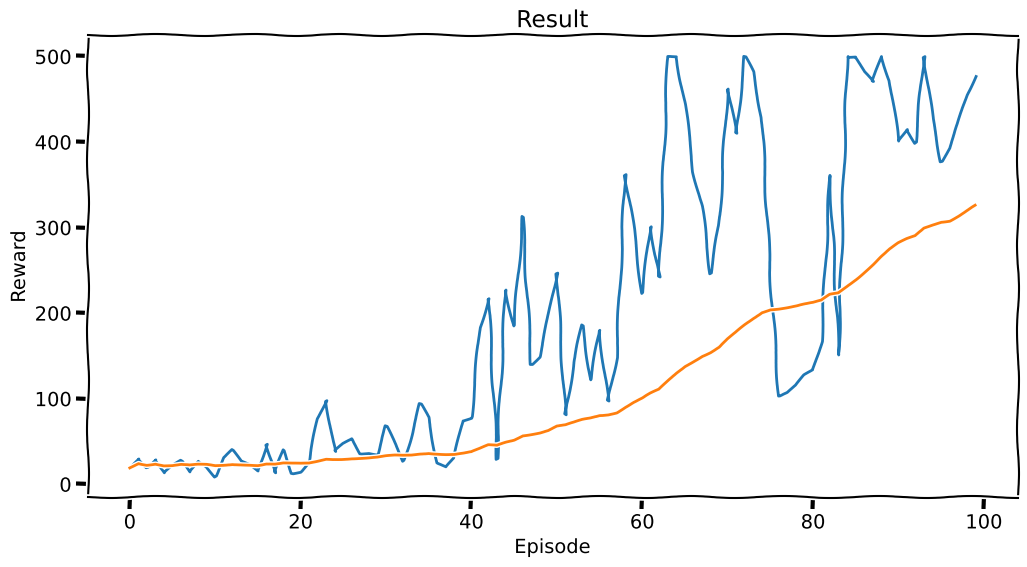

<Figure size 1200x600 with 0 Axes>

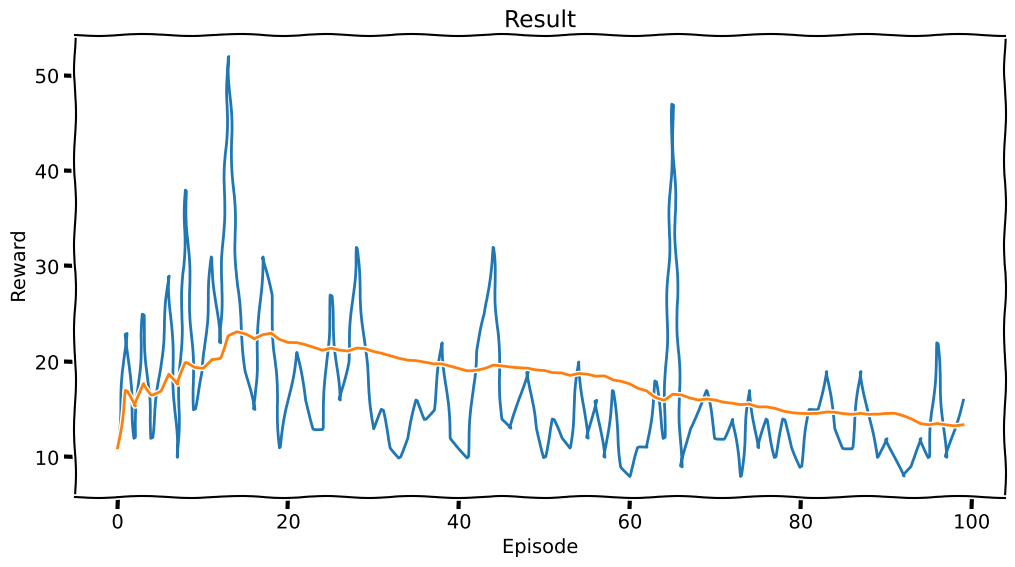

<Figure size 1200x600 with 0 Axes>

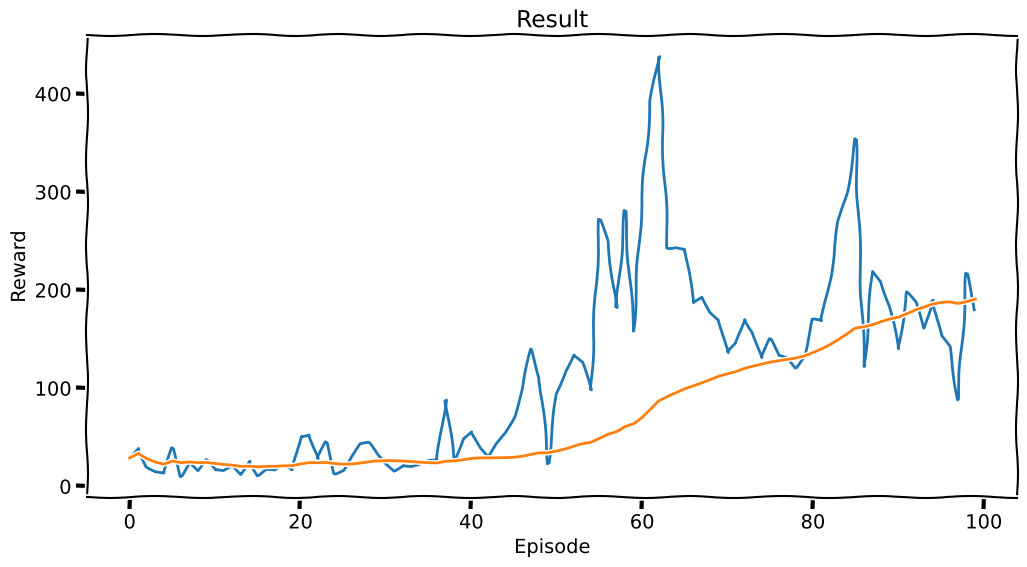

<Figure size 1200x600 with 0 Axes>

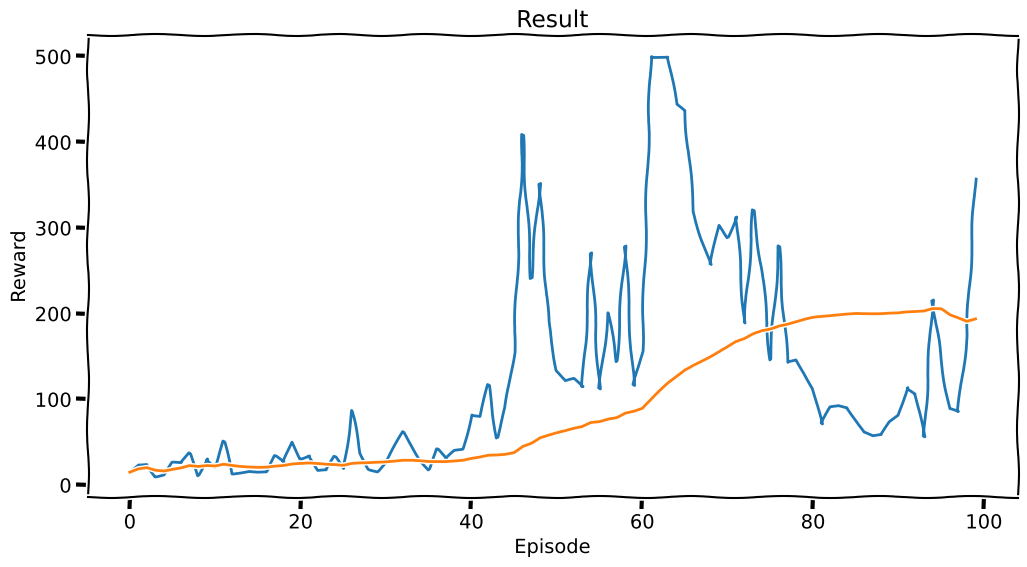

<Figure size 1200x600 with 0 Axes>

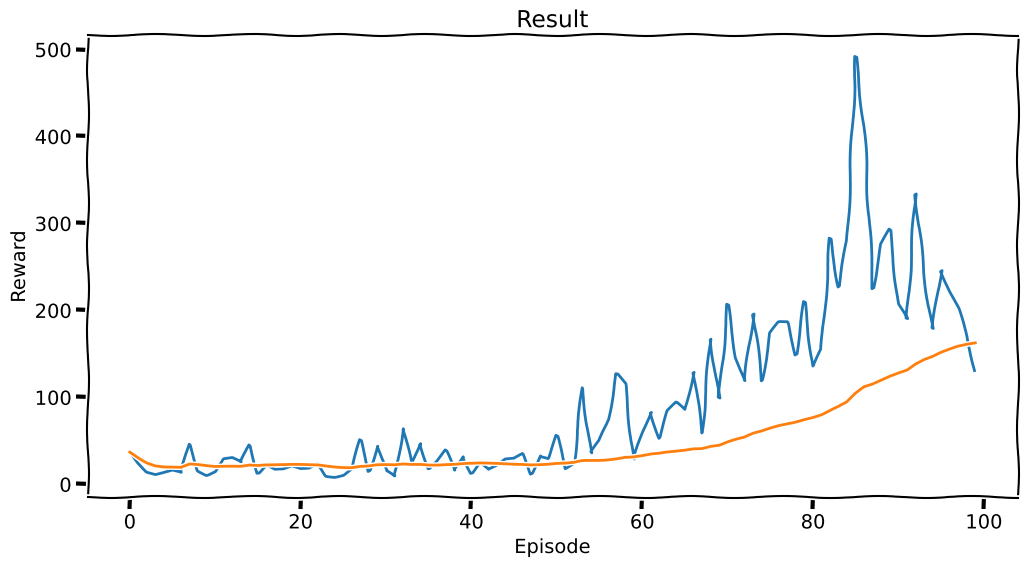

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [11]:
num_episodes = 100

for i, dqn_Agent in enumerate(DQN_agents):
    dqn_sum_of_rewards[i] = []

    for e in range(1, num_episodes + 1):
        state, _ = env.reset()
        episode_reward = 0

        while True:
            state_t = torch.from_numpy(state).float().unsqueeze(0).to(device)
            action, _ = dqn_Agent.act(state_t, greedy=False)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            next_state_t = torch.from_numpy(next_state).float().unsqueeze(0).to(device)
            dqn_Agent.step(state_t, action, reward, next_state_t, done)

            episode_reward = episode_reward + reward

            if done:
                break

            state = next_state

        dqn_sum_of_rewards[i].append(episode_reward)

        if e % 50 == 0:
            path = f'DQN_{i}_Network' + (str(len(dqn_sum_of_rewards[i]))).zfill(4)
            dqn_Agent.save(path)
            save_progress(dqn_sum_of_rewards[i], path)

for i in range(len(dqn_sum_of_rewards)):
    plot_rewards(dqn_sum_of_rewards[i], i, show_result=True)

## **Why DDQN?**  

DQN and its variants use a replay buffer and Q-network, but DQN struggles with learning stability. **Can you identify why?**  
To address this, we introduce DDQN—a modified version with improved stability, capable of handling more complex environments.  

---

## **DDQN Agent**  

### **Deep Q-Networks in DDQN**  

DDQN uses two networks:  

- **Online Network**: Estimates $Q_\theta(s_i,a_i)$, representing the value of a state-action pair.  its parameters is denoted with $\theta$
- **Target Network**: Estimates $Q_{\theta'}(s_i',a_i')$, representing the value of the next state-action pair.  its parameters is denoted with $\theta'$

Both networks have identical architectures but serve different roles. The target network helps stabilize training by reducing overestimation bias.  

### **Network Updating**  

In DQN, a single network estimates both $Q(s_i,a_i)$ and $Q(s_i',a_i')$, leading to instability. DDQN introduces a key change:  

- The **online network** selects the best action:  
  $$ \arg\max_a Q_\theta(s'_i,a) $$
- The **target network** estimates its value:  
  $$ Q_{\theta'}(s_i, \arg\max_a Q_\theta(s'_i,a)) $$  

This modifies the loss function to:  

$$ [r_i + \gamma \cdot Q_{\theta'}(s_i, \arg\max_a Q_\theta(s'_i,a)) - Q_\theta(s_i,a_i)]^2 $$  

In this version DDQN, we also use $\text{soft replacemet}$ which is not a part of original DDQN, that another modification that is applied.
*   `soft_update` : The target network is updated at every step with a soft update controlled by the hyperparameter $\tau$, which was previously defined. The target is updated according to: $$\theta' \leftarrow \tau \theta + (1 - \tau) \theta'$$

## DDQN Psudocode

<img src="figs/DDQN.png" style="margin-left: 300px;">  


Now, let's define the **DDQN class**.  


## **Impelementing DDQN Class (20 points)**

In [12]:
import copy
import random
import numpy as np
import torch

class DDQNAgent(object):

    def __init__(self, q_network, memory, optimizer, criterion, params):
        self.policy_net = q_network
        self.target_net = copy.deepcopy(self.policy_net)
        self.target_net.eval()

        self.reply_buffer = memory(params['BUFFER_SIZE'], params['BATCH_SIZE'])

        self.criterion = criterion()
        self.optimizer = optimizer(self.policy_net.parameters(), lr=params['LR'], amsgrad=True)

        self.tau = params['TAU']
        self.gamma = params['GAMMA']
        self.update_rate = params['UPDATE_RATE']
        self.eps = {'START': params['EPS_START'], 'END': params['EPS_END'], 'DECAY': params['EPS_DECAY']}
        self.steps_done = 0
        self.Loss = []

        self.soft_update(tau=1.0)

        with torch.no_grad():
            try:
                self.action_size = self.policy_net.fc3.out_features
            except Exception:
                self.action_size = None

    def step(self, state, action, reward, next_state, done):
        self.steps_done += 1
        self.reply_buffer.push(state, action, reward, next_state, done)

        if self.reply_buffer.get_size() > self.reply_buffer.batch_size:
            states, actions, rewards, next_states, dones = self.reply_buffer.sample()
            loss = self.learn(states, actions, rewards, next_states, dones)
            self.Loss.append(loss)

            if self.steps_done % self.update_rate == 0:
                self.soft_update(self.tau)

    def act(self, state, greedy=False, eps_threshold=None):
        self.eps_threshold = self.eps['END'] + (self.eps['START'] - self.eps['END']) * np.exp(- self.steps_done / self.eps['DECAY'])

        if greedy or random.random() > self.eps_threshold:
            with torch.no_grad():
                Q_values = self.policy_net(state)
                action = torch.argmax(Q_values, dim=1).item()
                max_Q = torch.max(Q_values).item()
        else:
            if self.action_size is None:
                with torch.no_grad():
                    Q_values = self.policy_net(state)
                self.action_size = Q_values.shape[1]
            action = random.randrange(self.action_size)
            max_Q = 0

        return action, max_Q

    def learn(self, states, actions, rewards, next_states, dones):
        states = torch.from_numpy(states).float().to(device)
        actions = torch.from_numpy(actions).long().to(device)
        rewards = torch.from_numpy(rewards).float().to(device)
        next_states = torch.from_numpy(next_states).float().to(device)
        dones = torch.from_numpy(dones).float().to(device)

        state_Q = self.policy_net(states).gather(1, actions)

        with torch.no_grad():
            best_next_actions = torch.argmax(self.policy_net(next_states), dim=1, keepdim=True)
            next_state_Q = self.target_net(next_states).gather(1, best_next_actions)
            target_Q = rewards + (self.gamma * next_state_Q * (1 - dones))

        loss = self.criterion(state_Q, target_Q)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def soft_update(self, tau):
        for target_param, policy_param in zip(self.target_net.parameters(), self.policy_net.parameters()):
            target_param.data.copy_(tau * policy_param.data + (1.0 - tau) * target_param.data)

    def save(self, PATH):
        torch.save(self.policy_net, PATH + '_policy.pt')
        torch.save(self.target_net, PATH + '_target.pt')

    def load(self, PATH):
        self.policy_net = torch.load(PATH + '_policy.pt')
        self.target_net = torch.load(PATH + '_target.pt')

## **Setting Up Essentials for DDQN (5 points)**  

- **CartPole Environment Setup**  
- **Hyperparameter Initialization**  
- **Creating DDQN Agents with Different Random Seeds**  
  - Why? Training multiple agents with different seeds helps assess DDQN's consistency and robustness.  
  - We use **5 random seeds** for better evaluation.  
- **Defining Optimizer and Loss Function**  


In [13]:
def create_ddqn_agent(seed, QNetwork, ReplayMemory, optimizer, criterion, params):
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

    q_net = QNetwork(params['N_OBS'], params['N_ACT']).to(device)
    return DDQNAgent(q_net, ReplayMemory, optimizer, criterion, params)


params = {
    'UPDATE_RATE': 10,
    'BUFFER_SIZE': 10000,
    'BATCH_SIZE': 64,
    'GAMMA': 0.99,
    'EPS_START': 1.0,
    'EPS_END': 0.05,
    'EPS_DECAY': 35000,
    'TAU': 0.008,
    'LR': 1e-3
}

seeds = [1, 10, 15, 43, 63]

env = gym.make("CartPole-v1")
env.reset()

n_actions = env.action_space.n
n_observations = env.observation_space.shape[0]

params['N_ACT'] = n_actions
params['N_OBS'] = n_observations

optimizer = torch.optim.AdamW
criterion = torch.nn.MSELoss

agents = []
sum_of_rewards = []

for seed in seeds:
    Agent = create_ddqn_agent(seed, QNetwork, ReplayMemory, optimizer, criterion, params)
    agents.append(Agent)
    sum_of_rewards.append([])

## **Training Loop for DDQN Agent (10 points)**  

With the hyperparameters set, we can now train the agent. The following code allows for easy re-training—if the agent's performance isn't satisfactory, simply re-run the segment to continue training for more episodes.  


/tmp/ipython-input-2925360218.py:30: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  init_means = np.cumsum(rewards[:init_len]) / (1 + np.arange(init_len))


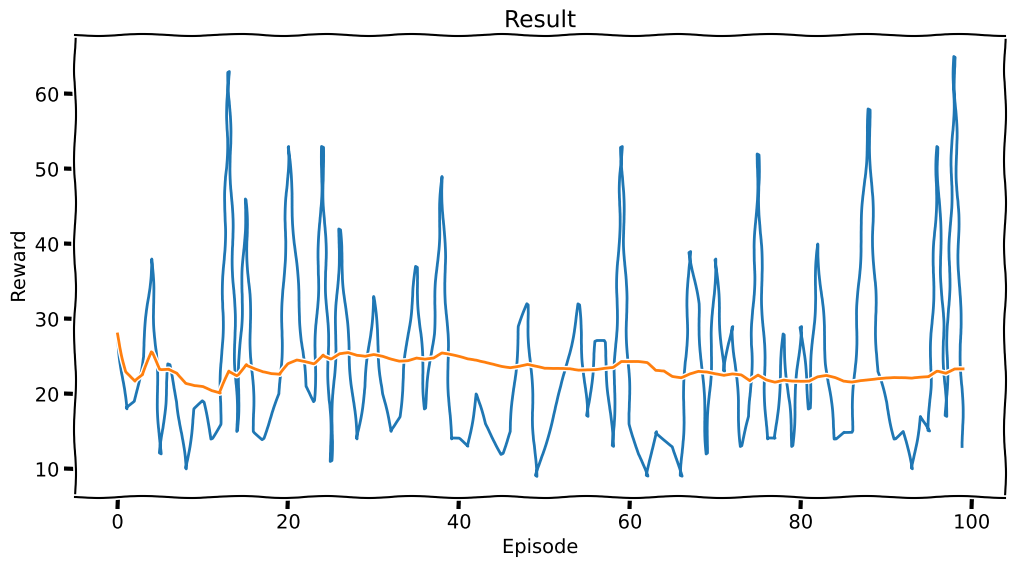

<Figure size 1200x600 with 0 Axes>

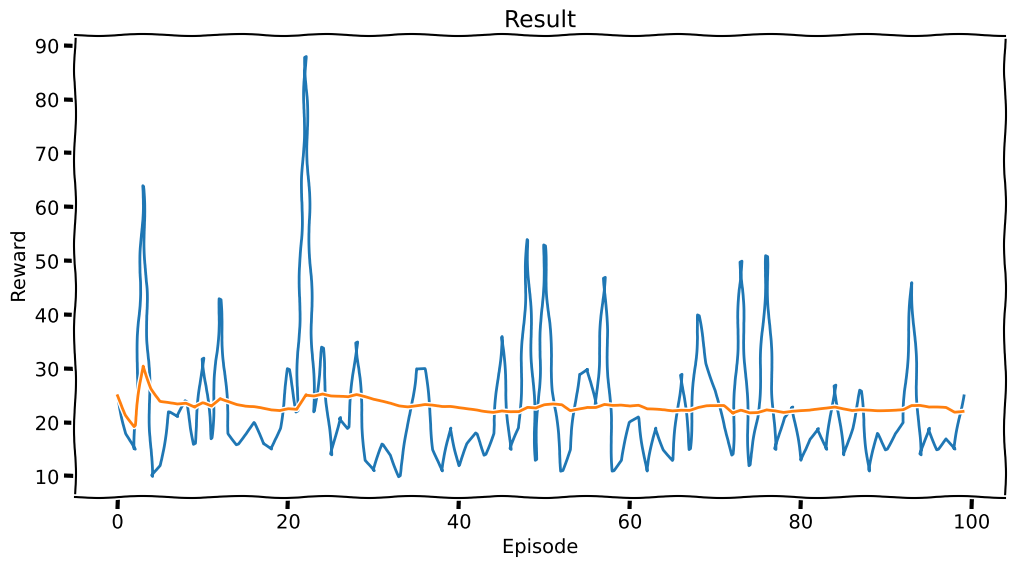

<Figure size 1200x600 with 0 Axes>

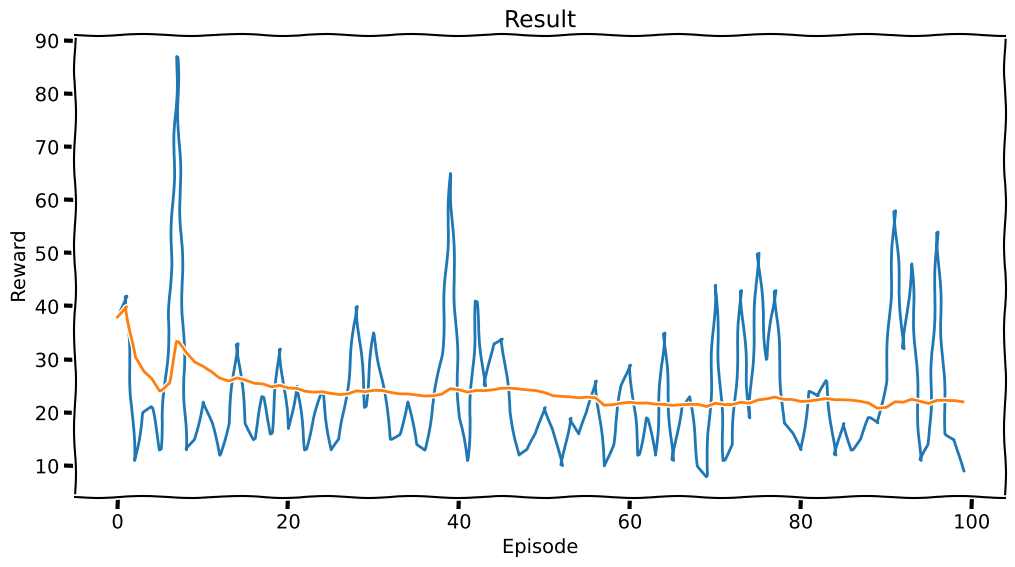

<Figure size 1200x600 with 0 Axes>

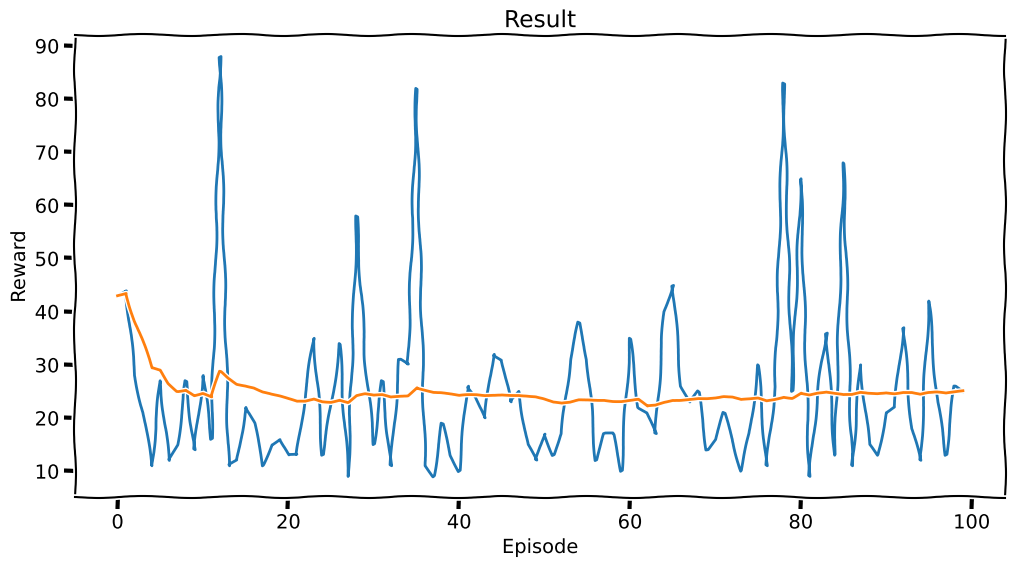

<Figure size 1200x600 with 0 Axes>

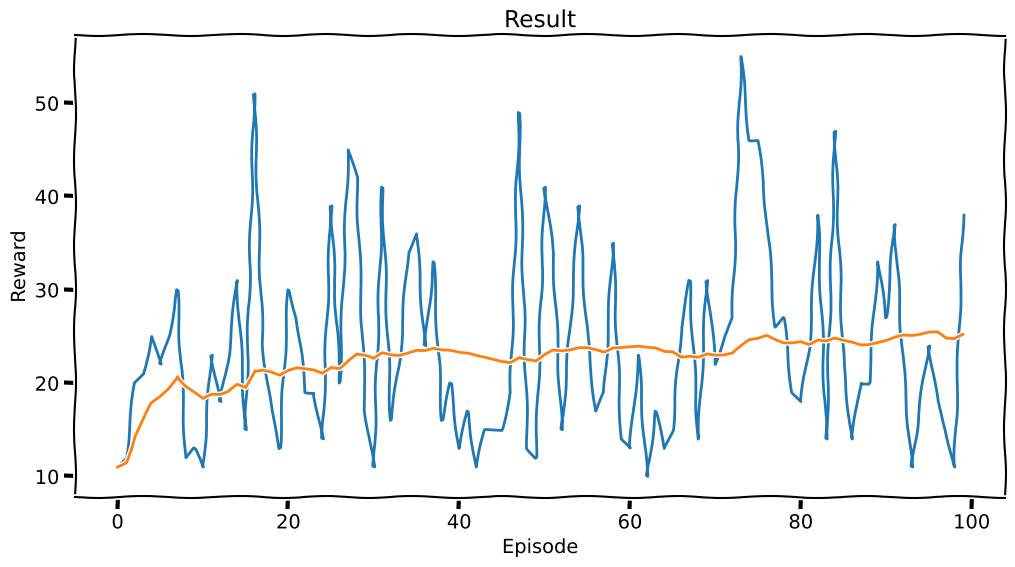

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [14]:
num_episodes = 100

for i, DDQN_agent in enumerate(agents):
    sum_of_rewards[i] = []

    for e in range(1, num_episodes + 1):
        state, _ = env.reset()
        episode_reward = 0

        while True:
            state_t = torch.from_numpy(state).float().unsqueeze(0).to(device)
            action, _ = DDQN_agent.act(state_t, greedy=False)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            next_state_t = torch.from_numpy(next_state).float().unsqueeze(0).to(device)
            DDQN_agent.step(state_t, action, reward, next_state_t, done)

            episode_reward += reward

            if done:
                break

            state = next_state

        sum_of_rewards[i].append(episode_reward)


        if e % 50 == 0:
            path = f'DDQN_{i}_Network' + (str(len(sum_of_rewards[i]))).zfill(4)
            DDQN_agent.save(path)
            save_progress(sum_of_rewards[i], path)

for i in range(len(sum_of_rewards)):
    plot_rewards(sum_of_rewards[i], i, show_result=True)

## **Computing the Moving Average of Results (5 points)**  

We compute a moving average to smooth the results for both DDQN and DQN across all seeds. This includes the average of the minimum, maximum, and actual returns across all seeds and episodes.  


In [15]:
import numpy as np

def moving_average(data, window_size=25):
    data = np.asarray(data, dtype=float).reshape(-1)
    if data.size == 0:
        return data
    window_size = int(window_size)
    if window_size <= 1:
        return data
    window_size = min(window_size, data.size)
    kernel = np.ones(window_size, dtype=float) / window_size
    return np.convolve(data, kernel, mode='valid')

def to_1d_float_list(seq):
    out = []
    for x in seq:
        if hasattr(x, "item"):
            x = x.item()
        out.append(float(x))
    return out

ddqn_lists = [to_1d_float_list(r) for r in sum_of_rewards if len(r) > 0]
dqn_lists  = [to_1d_float_list(r) for r in dqn_sum_of_rewards if len(r) > 0]

min_len_ddqn = min(map(len, ddqn_lists))
min_len_dqn  = min(map(len, dqn_lists))

ddqn_array = np.stack([np.array(r[:min_len_ddqn], dtype=float) for r in ddqn_lists], axis=0)
dqn_array  = np.stack([np.array(r[:min_len_dqn],  dtype=float) for r in dqn_lists],  axis=0)

DDQN_mean_rewards = moving_average(ddqn_array.mean(axis=0), window_size=25)
DDQN_min_rewards  = moving_average(ddqn_array.min(axis=0),  window_size=25)
DDQN_max_rewards  = moving_average(ddqn_array.max(axis=0),  window_size=25)

DQN_mean_rewards  = moving_average(dqn_array.mean(axis=0), window_size=25)
DQN_min_rewards   = moving_average(dqn_array.min(axis=0),  window_size=25)
DQN_max_rewards   = moving_average(dqn_array.max(axis=0),  window_size=25)

## **Visualizing the Outputs (5 points)**  

Plotting the smoothed results with:  
- Lower bound as the average of minimum returns  
- Upper bound as the average of maximum returns  
- Actual moving average of the returns  

for smoother plots, you can increase the **window_size** in `moving_average` function.


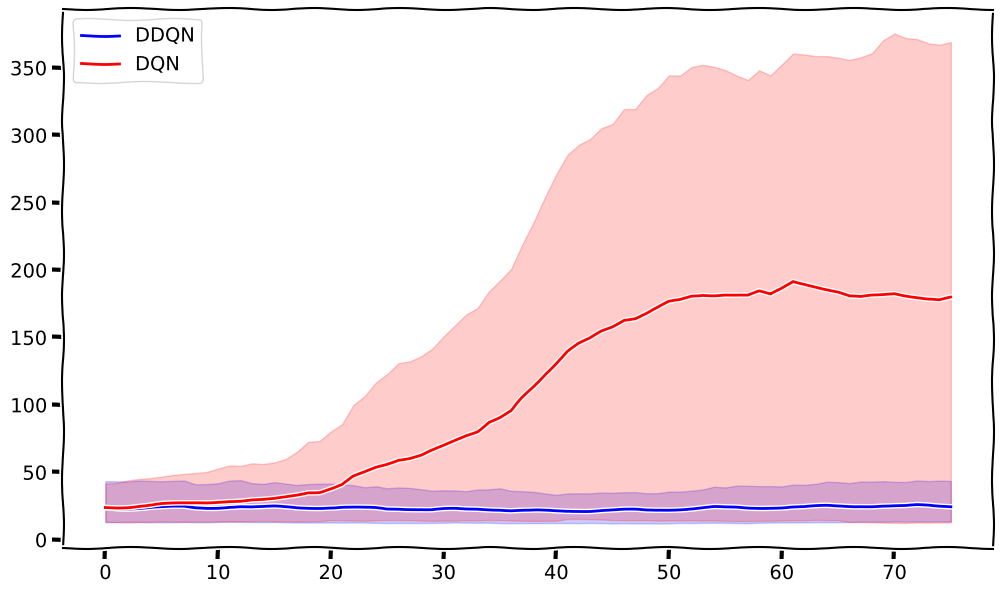

In [16]:
plot_smooth(DDQN_mean_rewards,DDQN_min_rewards,DDQN_max_rewards,DQN_mean_rewards,DQN_min_rewards,DQN_max_rewards)

## **Takeaway Questions**
- Which algorithm, DQN or DDQN, exhibits more stable learning?
    - Consider mean returns and the tightness of the upper and lower bounds in the training plot.

<div style="direction: rtl; text-align: right; font-family: Vazir;">
الگوریتم DDQN همیشه پایدار تر از DQN هست چون مشکل اصلی DQN اینه که در آپدیت ها از همون شبکه برای انتخاب اکشن و ارزش دهی استفاده میکنه و همین باعث میشه که overestimation رخ بده . حالا اگه با نمودار های بالا هم بخوام یه تحلیل بگم همون طور که در نمودار ها مشاهده میشه DDQN معموات mean return نرم تر و یکنواخت تر رشد میکنه . همچنین نوار عدم قطعیت در DDQN تنگ تره و این نشون میده که عملکرد اون در اپیزود های مختلف کمتر نوسان میکنه و یادگیریش قابل اعتماد تره . از اون طرف DQN بیشتر وقت ها نوسانش بیشتره که این باعث میشه در برخی موارد بد تصمیم بگیره .
</div>
- Which algorithm struggles less during learning?
<div style="direction: rtl; text-align: right; font-family: Vazir;">
DDQN کمتر struggle میکنه چون به خاطر کاهش overrestimation آپدیت ها کمتر گمراه کننده میشن و policy کمتر وارد فاز خوشبینی اشتباه میشه . همون طور که تو نمودار هم مشاهده میکنید DDQN زودتر از بازده های خیلی بد جدا میشه و افت های شدید و پرتکرار کمتری نسبت به DQN داره . همچنین واریانسش هم کمتره .
</div>

## **Model Evaluation (10 points)**  

To evaluate the model, we measure the **average reward** and its **standard deviation** using the following function.  


In [17]:
def evaluate_policy(env, agent, num_episodes=3):
    total_rewards = []
    Episode_values = []

    for episode in range(num_episodes):
        state, _ = env.reset()
        episode_reward = 0

        values = []
        mean_value = []

        while True:
            state_t = torch.from_numpy(state).float().unsqueeze(0).to(device)
            action, Q = agent.act(state_t, greedy=True)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            values.append(Q)
            mean_value.append(np.array(values).mean())

            episode_reward += reward

            if done:
                break

            state = next_state

        total_rewards.append(episode_reward)
        Episode_values.append(mean_value)

    mean = np.mean(total_rewards)
    std = np.std(total_rewards)

    return mean, std, Episode_values

**Run both trained policies for 3 episodes, observe the mean and std of returns, and plot the mean Q-values per episode. If the agent passes the evaluation bar, plot their mean values.**

## **Plot DDQN values**

In [18]:
DDQN_values = []

for i, DDQN_agent in enumerate(agents):
    mean_reward, std_reward, mean_values = evaluate_policy(env, DDQN_agent, num_episodes=3)
    print(f"evaluating the {i}th agent mean_reward = {mean_reward} +/- {std_reward}\n")

    if mean_reward >= 450:
        DDQN_values.append(mean_values)

if len(DDQN_values) != 0:
    plot_values(DDQN_values)
else:
    print('[Info] ... the Agent Did not pass the minimum requirement Please train it more.')

evaluating the 0th agent mean_reward = 10.0 +/- 0.0

evaluating the 1th agent mean_reward = 23.333333333333332 +/- 3.6817870057290873

evaluating the 2th agent mean_reward = 51.666666666666664 +/- 4.714045207910317

evaluating the 3th agent mean_reward = 96.0 +/- 10.424330514074594

evaluating the 4th agent mean_reward = 20.666666666666668 +/- 15.084944665313014

[Info] ... the Agent Did not pass the minimum requirement Please train it more.


## **Plot DQN values**

evaluating the 0th agent mean_reward = 494.33 +/- 8.01

evaluating the 1th agent mean_reward = 8.67 +/- 0.94

evaluating the 2th agent mean_reward = 208.00 +/- 35.81

evaluating the 3th agent mean_reward = 424.67 +/- 45.64

evaluating the 4th agent mean_reward = 243.33 +/- 46.15



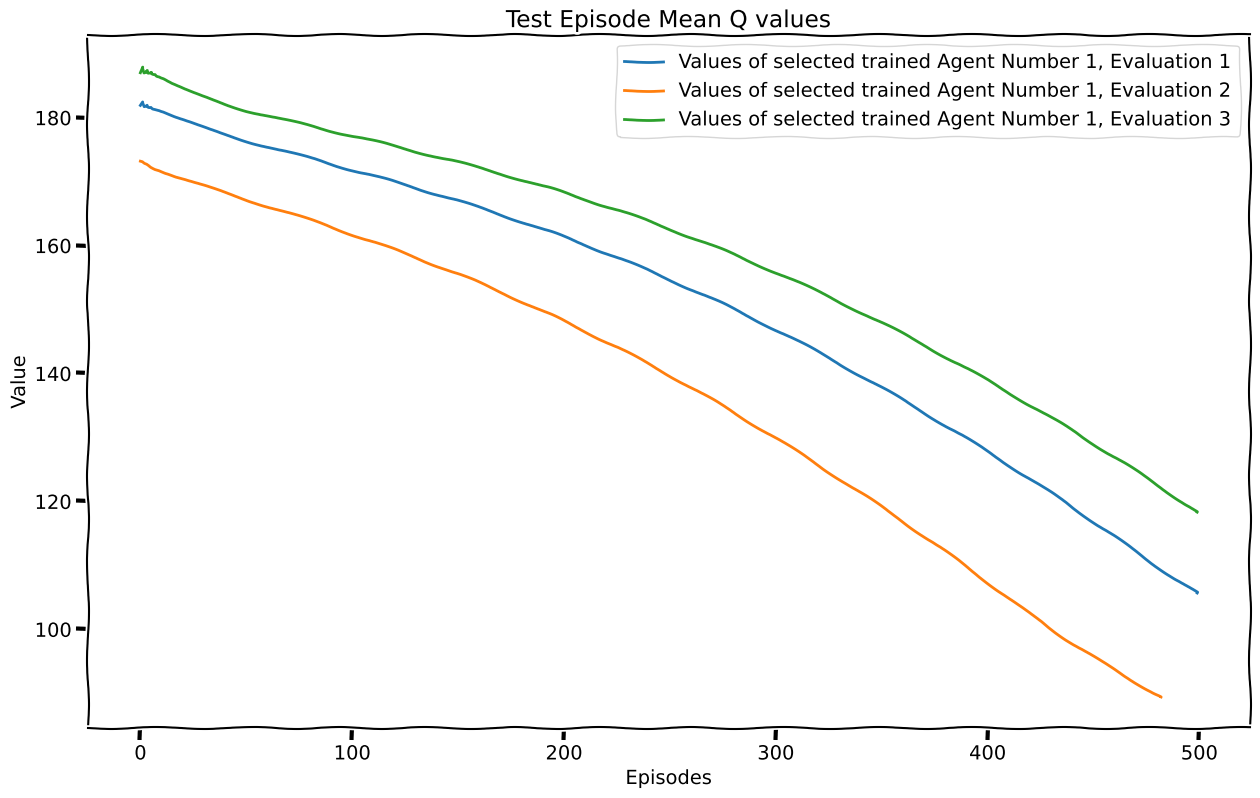

In [19]:
DQN_values = []
best_mean = -1e9
best_values = None

for i, DQN_agent in enumerate(DQN_agents):
    mean_reward, std_reward, mean_values = evaluate_policy(env, DQN_agent, num_episodes=3)
    print(f"evaluating the {i}th agent mean_reward = {mean_reward:.2f} +/- {std_reward:.2f}\n")

    if mean_reward > best_mean:
        best_mean = mean_reward
        best_values = mean_values

    if mean_reward >= 450:
        DQN_values.append(mean_values)

if len(DQN_values) != 0:
    plot_values(DQN_values)
else:
    print('[Info] No agent reached mean_reward >= 450. Plotting the best agent instead.')
    plot_values([best_values])

## **Watch the best Agent's performance (5 points)**
**Select one of the best agents from the evaluation step and render its performance.**

**Rendering DDQN Agent**

In [20]:
env = gym.make("CartPole-v1", render_mode="rgb_array")
print('[info] ... rendering the DDQN Agent performance')

best_agent = max(agents, key=lambda a: evaluate_policy(env, a, num_episodes=5)[0])
create_policy_eval_video(env, best_agent, 'DDQN_best_agent', num_episodes=5)

[info] ... rendering the DDQN Agent performance


**Rendering DQN Agent**

In [21]:
env = gym.make("CartPole-v1", render_mode="rgb_array")
print('[info] ... rendering the DQN Agent performance')

best_agent = max(DQN_agents, key=lambda a: evaluate_policy(env, a, num_episodes=5)[0])
create_policy_eval_video(env, best_agent, 'DQN_best_agent', num_episodes=5)

[info] ... rendering the DQN Agent performance


## **Takeaway Questions**
- Which agent is trained better considering the evaluation and rendering the performance?

<div style="direction: rtl; text-align: right; font-family: Vazir;">
DDQNبهتره چون مطابق ویدیو یا همون رندر عامل به سمت چپ حرکت میکنه و سعی میکنه میله رو صاف نگه داره و حرکات نوسانیش کمتره و همین نشون میده که سیاستش به الگوی کنترلی نسبتا ثابت رسیده و البته یکی از دلایل دیگه برتری DDQN اینه که پاداش دریافتیش بیشتره .
</div>

- One of the DDQN's goal is to prevent Q values over estimation. Did you observe this phenomenon after ploting the Mean Q values and comparing them to DQN values?

<div style="direction: rtl; text-align: right; font-family: Vazir;">
بله مطابق نمودار بالا پدیده بیش‌ برآورد Q در DQN دیده میشه . چون در نمودار مقادیر Q در برخی اجرا های DQN در ابتدا خیلی بزرگ تر از مقدار پایدار هست و سپس با ادامه یادگیری کم شدند که همین نشون دهنده تخمین خوشبینانه اولیه هست . اما در مقابل در DDQN مقادیر Q پایدار تر و کنترل شده تری تولید شده و همین با عملکرد کلی سازگار تر هست . بنابراین DDQN تونسته مشکل overestimation موجود در DQN رو کم کنه
</div>
